## ST3131 Regression Analysis - Individual Assignment Code - Nabil Rakaiza Abror

This file contains the code used to complete the assignment. Please note that a third-party API is utilized to retrieve specific features; the required API token can be obtained from the provided link. Alternatively, to bypass the data preprocessing stage, you may begin directly at the Exploratory Data Analysis (EDA) section using the provided pre-cleaned dataset.

### Importing Libraries

In [ ]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import requests
import math
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.linalg import toeplitz
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from statsmodels.tools.tools import add_constant
import scipy.stats as stats

import warnings
warnings.filterwarnings('ignore')

# API token from OneMap https://www.onemap.gov.sg/
API_TOKEN = "PUT_YOUR_ONEMAP_API_TOKEN_HERE"

### Reading Data and Preprocesing

The following preprocessing steps were performed on the dataset, along with their respective justifications:
- __Dropping the month column:__ This variable contains a single unique value (July 2020). Because it provides no variance, it offers no predictive value for the model and was consequently removed.
- __Standardizing remaining_lease:__ Regular expressions (regex) were utilized to convert the "XX years XX months" string format into an integer representing the total number of months. This transforms the data into a usable numerical feature.
- __Feature engineering for location data:__ Because the block and street_name variables are highly dimensional and suboptimal for a linear model, a third-party API was employed to retrieve their corresponding latitudes, longitudes, and postal codes. These geographic coordinates were then used to compute distance-based metrics, specifically the distance to the city center (Raffles Place) and the distance to the nearest MRT station.
- __Transforming storey_range:__ Initially formatted as a categorical feature, this variable was converted into a numerical one by extracting the midpoint value of each specified range.

In [56]:
data = pd.read_csv("hdb-resale-July-2020.csv")
data.head()

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price
0,2020-07,ANG MO KIO,2 ROOM,314,ANG MO KIO AVE 3,04 TO 06,44.0,Improved,1978,56 years 07 months,198000.0
1,2020-07,ANG MO KIO,2 ROOM,314,ANG MO KIO AVE 3,04 TO 06,44.0,Improved,1978,56 years 06 months,207000.0
2,2020-07,ANG MO KIO,2 ROOM,510,ANG MO KIO AVE 8,01 TO 03,44.0,Improved,1980,59 years,198000.0
3,2020-07,ANG MO KIO,2 ROOM,508,ANG MO KIO AVE 8,01 TO 03,44.0,Improved,1980,58 years 11 months,208000.0
4,2020-07,ANG MO KIO,3 ROOM,218,ANG MO KIO AVE 1,10 TO 12,82.0,New Generation,1976,54 years 11 months,290000.0


In [57]:
# need to drop since there is only one unique value, thus not contributing anything to analysis
data = data.drop(columns=["month"])

# using regex to transform remaining_lease to be stored as a number instead (number of months)
pattern = r'(?P<years>\d+)\s*years?(?:\s*(?P<months>\d+)\s*months?)?'
remaining_lease = data["remaining_lease"].str.extract(pattern)
remaining_lease["months"] = remaining_lease["months"].fillna(0).astype(int)
remaining_lease["years"] = remaining_lease["years"].fillna(0).astype(int)
data["remaining_lease"] = (remaining_lease['years'] * 12) + remaining_lease['months']

In [58]:
# block and streetname is not really useful in its raw state, we will transform it to longitude, latitude, and postal code
data["address"] = data["block"] + " " + data["street_name"]
unique_addresses = data["address"].unique()

# helper function to get latitude, longitude, and postal values
def get_coordinates(search_val, token):
    try:
        url = f"https://www.onemap.gov.sg/api/common/elastic/search?searchVal={search_val}&returnGeom=Y&getAddrDetails=Y&pageNum=1"
        headers = {
            "Authorization": token
        }
        
        response = requests.get(url, headers=headers)
        if response.status_code == 200:
            data = response.json()
            if data['found'] > 0:
                result = data['results'][0] # The first result is usually the most accurate
                return {
                    "lat": result['LATITUDE'],
                    "lon": result['LONGITUDE'],
                    "postal": result['POSTAL']
                }
    except Exception as e:
        print(f"Error fetching location data: {e}")
    return None

In [ ]:
# getting all address data from the unique addresses, and then will put it inside dataframe
address_data = {}
for addr in unique_addresses:
    coords = get_coordinates(addr, API_TOKEN)
    if coords:
        address_data[addr] = coords
    else:
        address_data[addr] = {"lat": None, "lon": None, "postal": None}

data["lat"] = data["address"].map(lambda x: address_data[x]["lat"])
data["lon"] = data["address"].map(lambda x: address_data[x]["lon"])
data["postal"] = data["address"].map(lambda x: address_data[x]["postal"])

In [60]:
# getting distance to nearest MRT and also distance to city (CBD Raffles Place)

CBD_LAT, CBD_LON = 1.2839, 103.8515

def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371 # Earth radius in km
    dlat = math.radians(float(lat2) - float(lat1))
    dlon = math.radians(float(lon2) - float(lon1))
    a = math.sin(dlat/2)**2 + math.cos(math.radians(float(lat1))) * \
        math.cos(math.radians(float(lat2))) * math.sin(dlon/2)**2
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1-a))
    return R * c

# getting mrt data
mrt_url = "https://raw.githubusercontent.com/xkjyeah/MRT-and-LRT-Stations/master/mrt_lrt.csv"
mrt_df = pd.read_csv(mrt_url)

def find_nearest_mrt_distance(hdb_lat, hdb_lon, mrt_df):
    mrt_coords = list(zip(mrt_df["Latitude"].tolist(), mrt_df["Longitude"].tolist()))
    distance = float("inf")

    for mrt_coord in mrt_coords:
        distance = min(distance, haversine_distance(hdb_lat, hdb_lon, mrt_coord[0], mrt_coord[1]))
    
    return distance

for addr, info in address_data.items():
    info['dist_to_cbd'] = haversine_distance(info['lat'], info['lon'], CBD_LAT, CBD_LON)
    info['dist_to_mrt'] = find_nearest_mrt_distance(info['lat'], info['lon'], mrt_df)

data["dist_to_cbd"] = data["address"].map(lambda x: address_data[x]['dist_to_cbd'])
data["dist_to_mrt"] = data["address"].map(lambda x: address_data[x]['dist_to_mrt'])

In [ ]:
# since storey_range is a string, need to convert to number by getting the middle value
data['storey_avg'] = data['storey_range'].str.extract(r'(\d+) TO (\d+)').astype(float).mean(axis=1)

In [74]:
data["lat"] = data["lat"].astype("float64")
data["lon"] = data["lon"].astype("float64")

#### Saving data to local

In [75]:
data.to_csv("cleaned_data.csv", index=False)

### Exploratory Data Analysis (EDA)

The Exploratory Data Analysis (EDA) phase investigates the underlying data distributions and the relationships between the regressors and the response variable. The following procedures were conducted during this stage:
- __Variable Selection:__ Removed columns that lacked predictive relevance to the model.
- __Distribution Analysis:__ Generated histograms to visualize the distributions of all numerical features, including the target variable.
- __Numerical Relationships:__ Constructed scatterplots to examine potential correlations between the numerical predictors and the target variable.
- __Categorical Relationships:__ Created boxplots to assess the associations between the categorical features and the target variable.
- __Addressing Multicollinearity:__ Identified high multicollinearity between two predictor variables, resulting in the exclusion of one to satisfy regression assumptions.

In [392]:
data = pd.read_csv("cleaned_data.csv")

# dropping several not-so-relevant features
data = data.drop(columns = ["block", "street_name", "postal", "address"])

categorical = [col for col in data.columns if data[col].dtype == 'object' or data[col].dtype.name == 'category']
numerical = [col for col in data.columns if data[col].dtype in ['int64', 'float64']]
numerical.remove("resale_price")

target = "resale_price"

#### Histogram of numerical variable

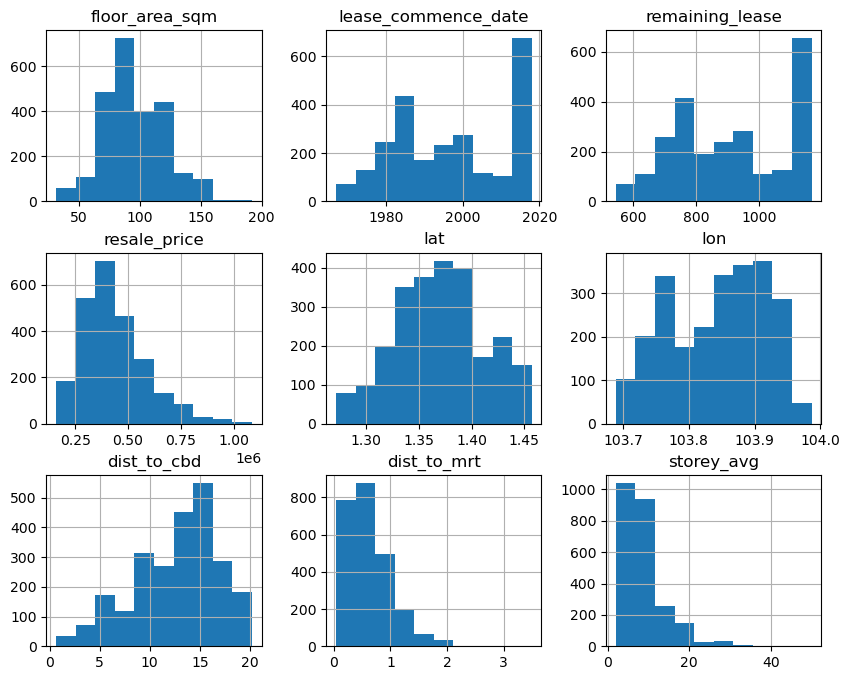

In [393]:
data.hist(figsize=(10, 8))
plt.show()

Comments: 

- The lease_commence_date and remaining_lease variables exhibit nearly identical distributions. This suggests potential multicollinearity, which will be further investigated in subsequent sections.
- The target variable, resale_price, deviates from a normal distribution and displays a positive (right) skew.
- Regarding the remaining predictors: dist_to_mrt and storey_avg exhibit positive skews, while dist_to_cbd demonstrates a slight negative (left) skew. The longitude variable (lon) presents a bimodal distribution, and floor_area_sqm approximately follows a normal distribution.

#### Scatter plot

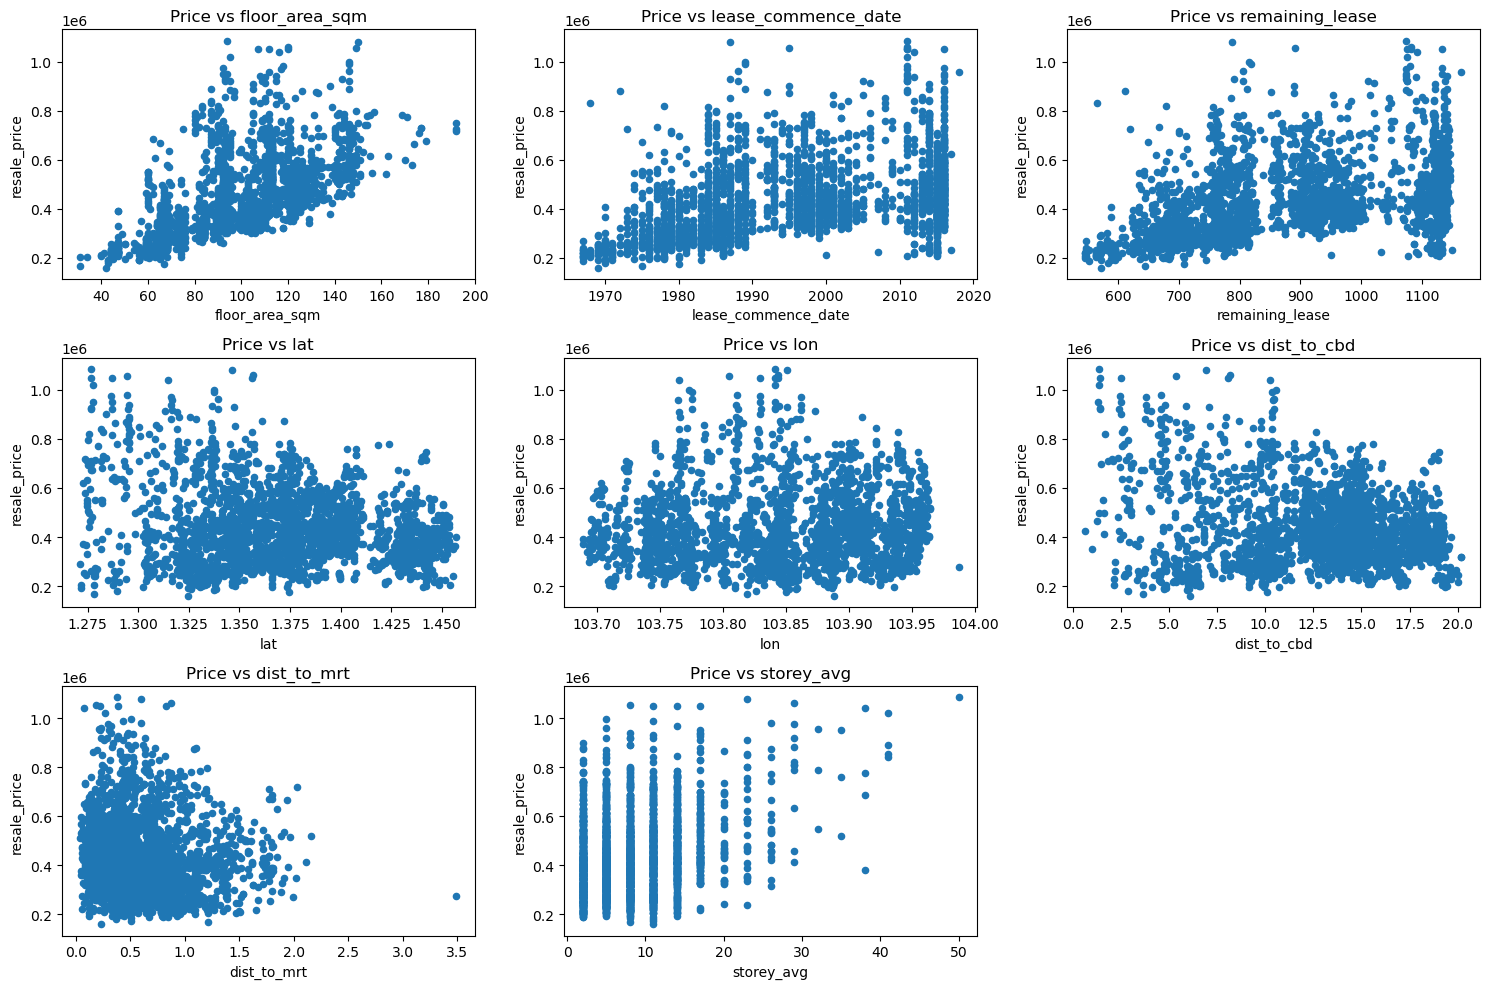

In [394]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(numerical):
    data.plot.scatter(x=col, y="resale_price", ax=axes[i])
    axes[i].set_title(f"Price vs {col}")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Comments: 

- There is an observable positive correlation between resale_price and both floor_area_sqm and storey_avg.
- Conversely, a negative correlation appears to exist between resale_price and dist_to_mrt.
- None of the independent variables exhibit a perfectly linear relationship with the target variable; rather, they demonstrate moderate positive or negative linear associations.
- Most predictors display considerable dispersion, meaning the variance in resale_price fluctuates significantly as the values of the predictor variables change.

#### Box Plot

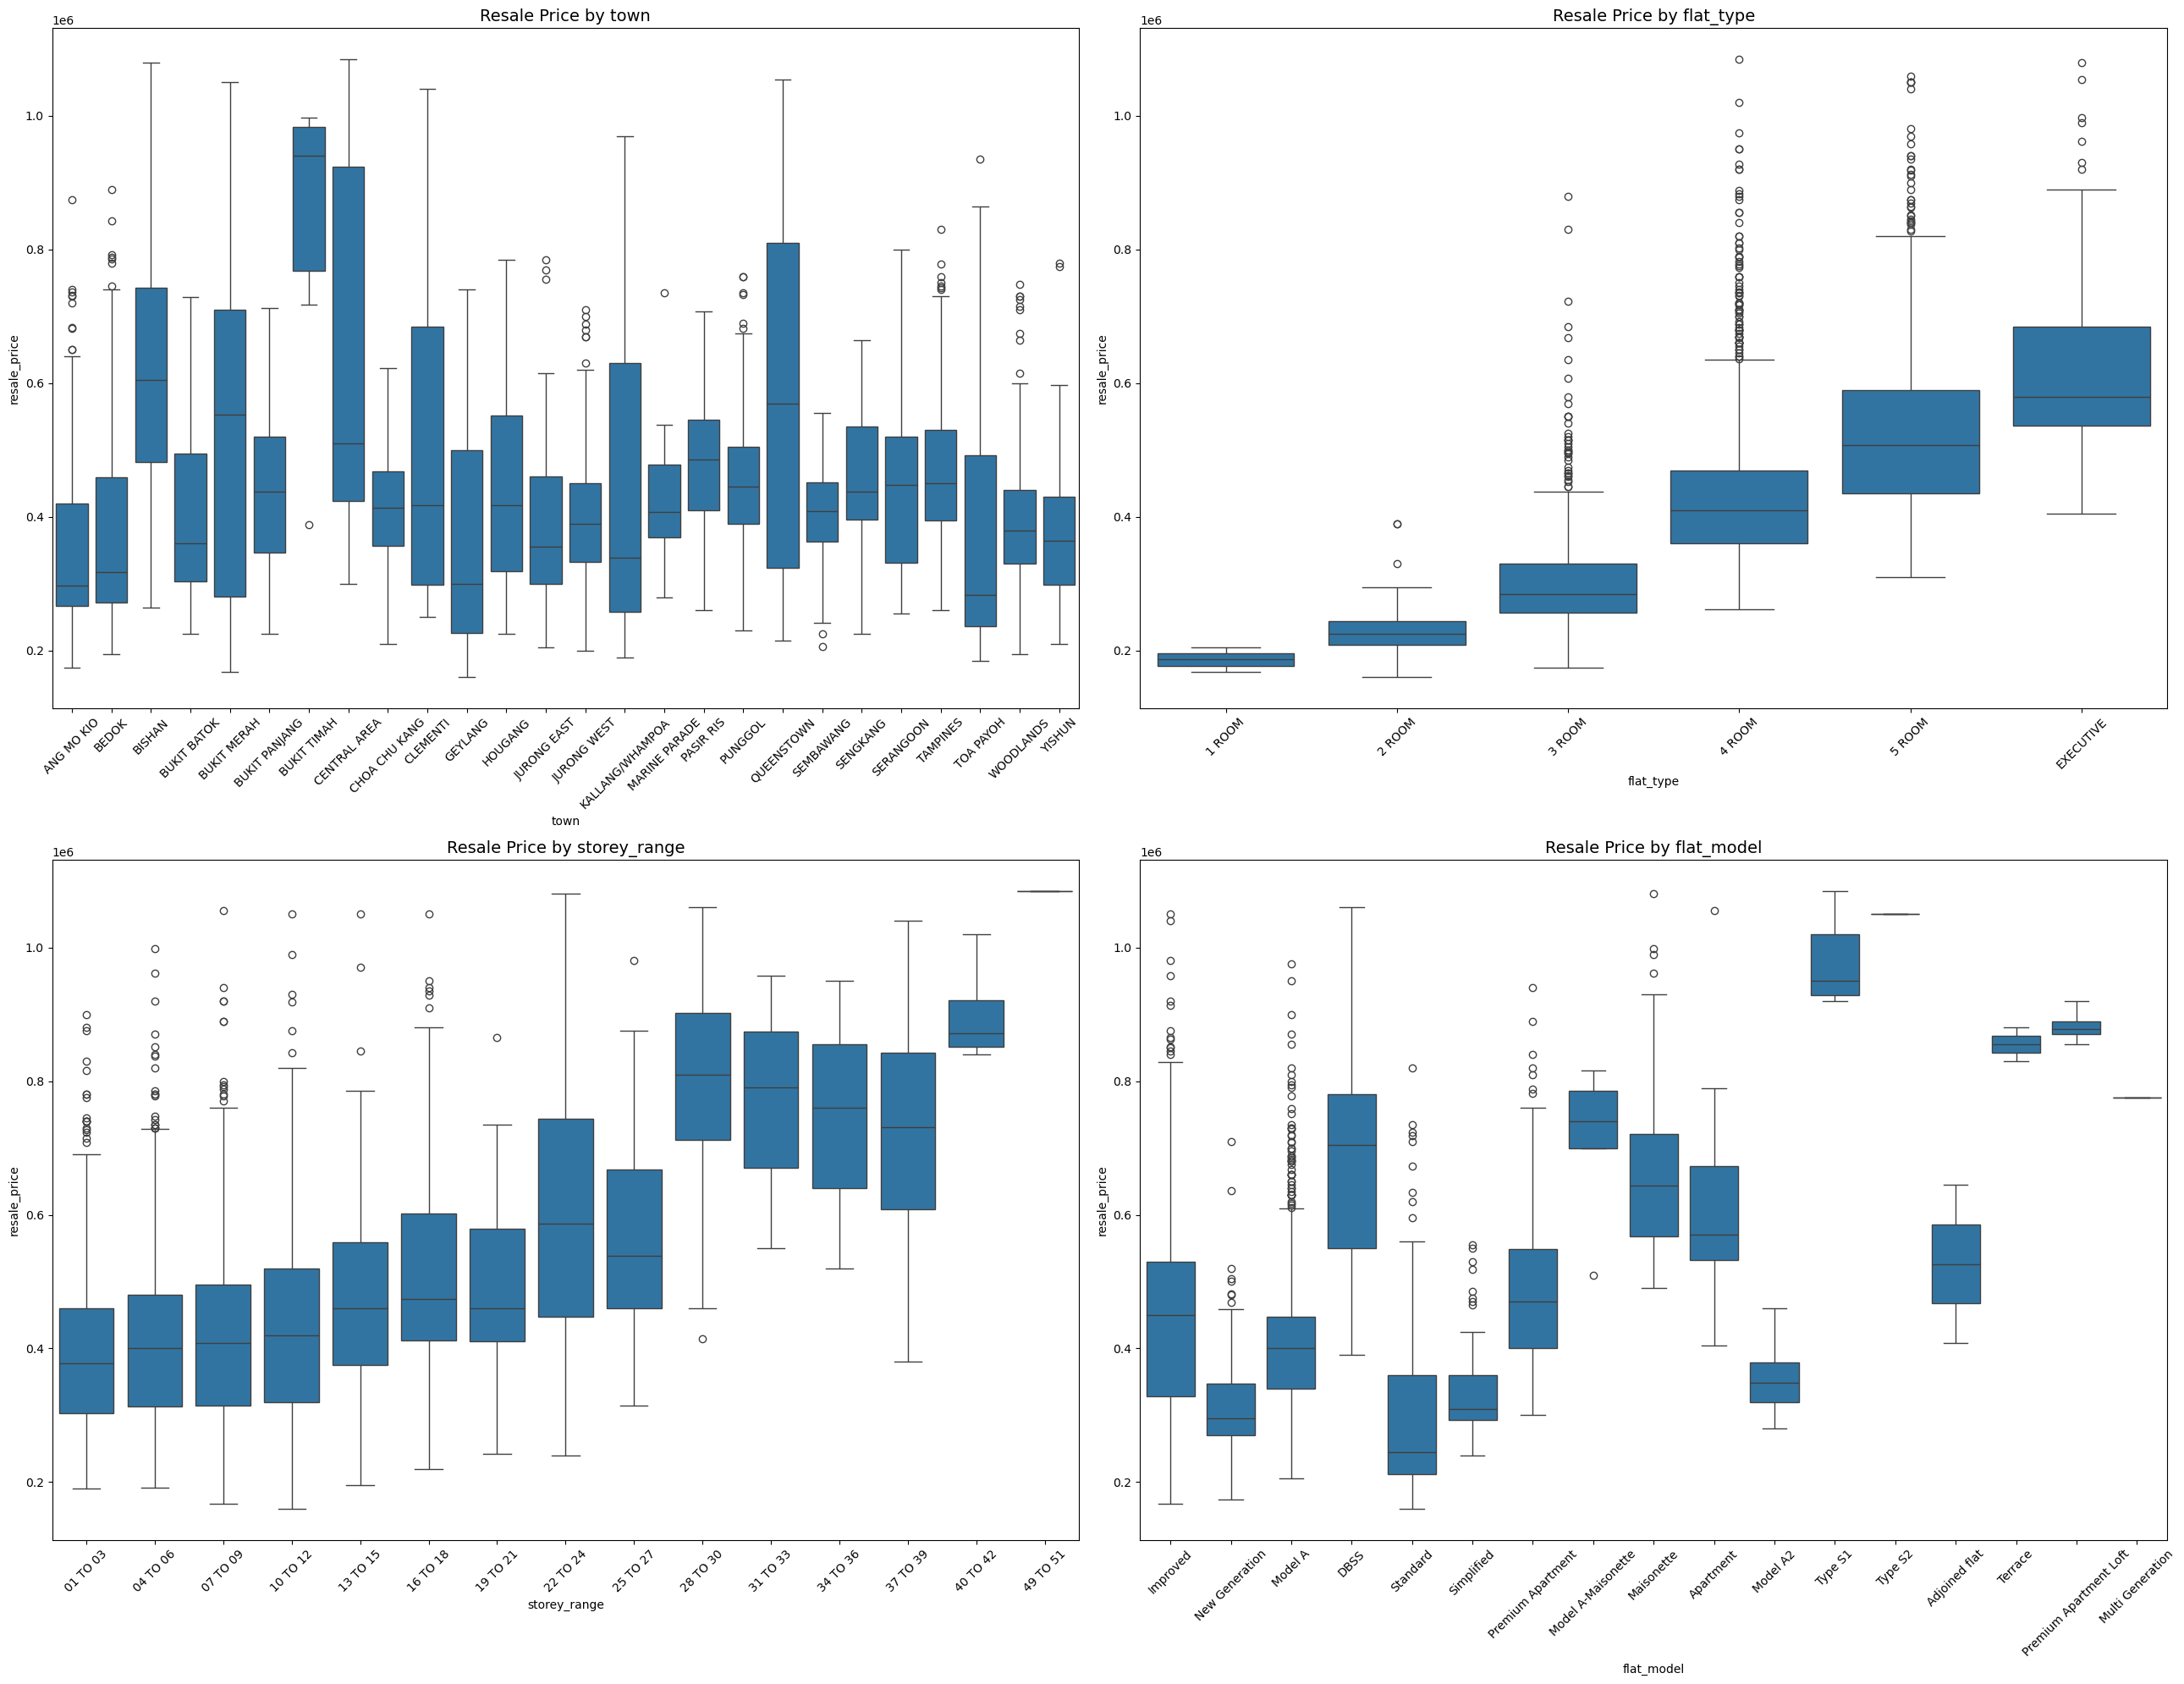

In [395]:
fig, axes = plt.subplots(2, 2, figsize=(26, 20))
axes = axes.flatten()

for i, col in enumerate(categorical):
    if col == "flat_type":
        manual_order = ["1 ROOM", "2 ROOM", "3 ROOM", "4 ROOM", "5 ROOM", "EXECUTIVE"]
        sns.boxplot(x=col, y='resale_price', data=data, ax=axes[i], order=manual_order)
        axes[i].set_title(f'Resale Price by {col}', fontsize=14)
        axes[i].tick_params(axis='x', rotation=45)
        continue

    if col == "storey_range":
        manual_order = ['01 TO 03', '04 TO 06', '07 TO 09', '10 TO 12', '13 TO 15', '16 TO 18', '19 TO 21', '22 TO 24', '25 TO 27', '28 TO 30', '31 TO 33', '34 TO 36', '37 TO 39', '40 TO 42', '49 TO 51']
        sns.boxplot(x=col, y='resale_price', data=data, ax=axes[i], order=manual_order)
        axes[i].set_title(f'Resale Price by {col}', fontsize=14)
        axes[i].tick_params(axis='x', rotation=45)
        continue

    sns.boxplot(x=col, y='resale_price', data=data, ax=axes[i])
    axes[i].set_title(f'Resale Price by {col}', fontsize=14)
    axes[i].tick_params(axis='x', rotation=45)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Comments: 

- A positive trend is observed where units located on higher storeys generally command a higher resale_price.
- Similarly, an increase in the number of rooms is positively associated with a higher resale_price.
- The resale_price exhibits significant variation across different towns, indicating a strong spatial influence.
- Similarly, The resale_price also exhibits significant variation across different flat_model.
- Specific flat models, such as Type S1, Terrace, and Premium Apartment Loft, consistently demonstrate higher resale prices relative to standard models.

#### Additional Checking

Following this observation below, one of the correlated features was removed prior to model fitting. This step was taken to ensure that these two variables do not introduce multicollinearity into the initial model.

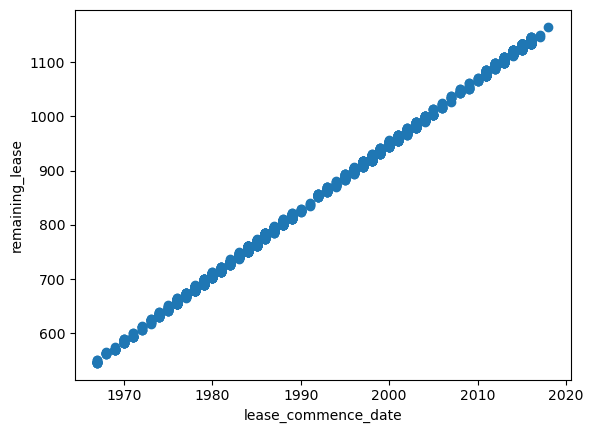

In [396]:
plt.scatter(data["lease_commence_date"], data["remaining_lease"])
plt.xlabel("lease_commence_date")
plt.ylabel("remaining_lease")
plt.show()

### Modelling

#### Initial Model

The initial phase of this step involves fitting a baseline Multiple Linear Regression (MLR) model. Subsequently, the model's assumptions and validity will be evaluated using Variance Inflation Factor (VIF) analysis, residual diagnostics, Analysis of Variance (ANOVA), and other relevant goodness-of-fit metrics. In the initial models, below are the list of variables that will be used as a predictor:

- town
- flat_type
- flat_model
- storey_avg
- floor_area_sqm
- remaining_lease
- dist_to_cbd
- dist_to_mrt
- lat
- lon

In [397]:
M0 = smf.ols(
    formula='resale_price ~ town + flat_type + flat_model + storey_avg + floor_area_sqm + remaining_lease + dist_to_cbd + dist_to_mrt + lat + lon', 
    data=data).fit()
M0.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           resale_price   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.895
Method:                 Least Squares   F-statistic:                     394.9
Date:                Thu, 09 Apr 2026   Prob (F-statistic):               0.00
Time:                        11:40:13   Log-Likelihood:                -30003.
No. Observations:                2456   AIC:                         6.011e+04
Df Residuals:                    2402   BIC:                         6.043e+04
Df Model:                          53                                         
Covariance Type:            nonrobust                                         
========================================================================================================
                                           coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
Intercept                            -6.457e+06   1.27e+07     -0.510      0.610   -3.13e+07    1.84e+07
town[T.BEDOK]                        -1.727e+04   1.34e+04     -1.286      0.198   -4.36e+04    9059.710
town[T.BISHAN]                        1.047e+05   1.15e+04      9.091      0.000    8.21e+04    1.27e+05
town[T.BUKIT BATOK]                  -3.265e+04   1.74e+04     -1.876      0.061   -6.68e+04    1477.550
town[T.BUKIT MERAH]                   5.514e+04   1.76e+04      3.132      0.002    2.06e+04    8.97e+04
town[T.BUKIT PANJANG]                -8.282e+04   1.41e+04     -5.858      0.000   -1.11e+05   -5.51e+04
town[T.BUKIT TIMAH]                   2.176e+05   2.45e+04      8.868      0.000     1.7e+05    2.66e+05
town[T.CENTRAL AREA]                  4.003e+04   1.95e+04      2.054      0.040    1820.877    7.82e+04
town[T.CHOA CHU KANG]                -8.283e+04   1.77e+04     -4.675      0.000   -1.18e+05   -4.81e+04
town[T.CLEMENTI]                      3.229e+04   1.86e+04      1.732      0.083   -4271.807    6.88e+04
town[T.GEYLANG]                      -1.493e+04   1.21e+04     -1.229      0.219   -3.88e+04    8892.409
town[T.HOUGANG]                      -4.312e+04   8689.945     -4.962      0.000   -6.02e+04   -2.61e+04
town[T.JURONG EAST]                  -9308.1568   2.11e+04     -0.441      0.659   -5.07e+04    3.21e+04
town[T.JURONG WEST]                  -1.869e+04   2.54e+04     -0.736      0.462   -6.85e+04    3.11e+04
town[T.KALLANG/WHAMPOA]               -241.2039   1.26e+04     -0.019      0.985    -2.5e+04    2.45e+04
town[T.MARINE PARADE]                 9.401e+04   2.02e+04      4.661      0.000    5.45e+04    1.34e+05
town[T.PASIR RIS]                    -9743.2499   1.66e+04     -0.588      0.557   -4.23e+04    2.28e+04
town[T.PUNGGOL]                      -6.863e+04   1.26e+04     -5.442      0.000   -9.34e+04   -4.39e+04
town[T.QUEENSTOWN]                    8.704e+04   1.66e+04      5.234      0.000    5.44e+04     1.2e+05
town[T.SEMBAWANG]                    -7.141e+04   1.63e+04     -4.387      0.000   -1.03e+05   -3.95e+04
town[T.SENGKANG]                     -1.161e+05   9828.853    -11.817      0.000   -1.35e+05   -9.69e+04
town[T.SERANGOON]                     2.781e+04   1.06e+04      2.613      0.009    6942.470    4.87e+04
town[T.TAMPINES]                     -2352.8919   1.55e+04     -0.152      0.879   -3.27e+04     2.8e+04
town[T.TOA PAYOH]                     1570.7770   9994.292      0.157      0.875    -1.8e+04    2.12e+04
town[T.WOODLANDS]                    -4.311e+04   1.52e+04     -2.837      0.005   -7.29e+04   -1.33e+04
town[T.YISHUN]                       -1.943e+04   1.18e+04     -1.647      0.100   -4.26e+04    3703.536
flat_type[T.2 ROOM]                   

In [398]:
anova_table = sm.stats.anova_lm(M0, typ=1)
anova_table

,df,sum_sq,mean_sq,F,PR(>F)
town,25.0,7.920250e+12,3.168100e+11,129.661080,0.000000e+00
flat_type,6.0,2.841436e+13,4.735727e+12,1938.194859,0.000000e+00
flat_model,16.0,8.856571e+12,5.535357e+11,226.546002,0.000000e+00
storey_avg,1.0,1.821508e+12,1.821508e+12,745.490130,3.441514e-143
floor_area_sqm,1.0,4.900670e+10,4.900670e+10,20.057009,7.868409e-06
remaining_lease,1.0,3.097961e+12,3.097961e+12,1267.905042,2.289709e-223
dist_to_cbd,1.0,1.981534e+11,1.981534e+11,81.098404,4.264516e-19
dist_to_mrt,1.0,7.785349e+11,7.785349e+11,318.631584,5.078926e-67
lat,1.0,9.089550e+08,9.089550e+08,0.372009,5.419691e-01
lon,1.0,6.332911e+08,6.332911e+08,0.259188,6.107256e-01


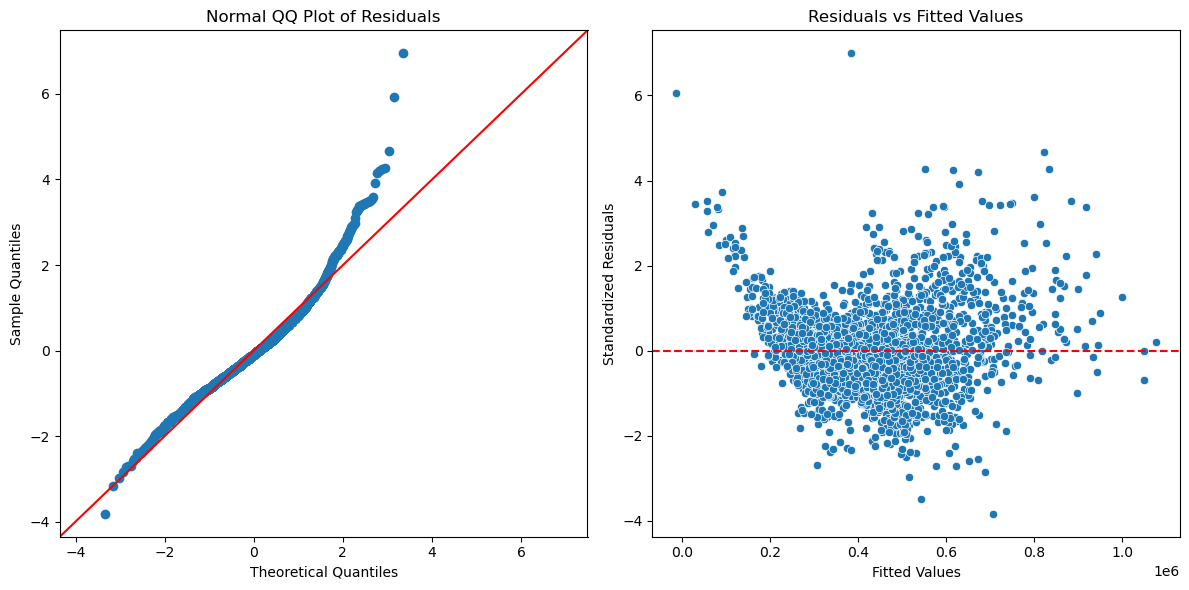

In [399]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

residuals = M0.resid
fitted_values = M0.fittedvalues
standardized_residuals = M0.get_influence().resid_studentized_internal

# Plot 1: QQ Plot
sm.qqplot(residuals, line='45', fit=True, ax=axes[0])
axes[0].set_title("Normal QQ Plot of Residuals")

# Plot 2: Residuals vs Fitted
sns.scatterplot(x=fitted_values, y=standardized_residuals, ax=axes[1])
axes[1].axhline(y=0, color='red', linestyle='--')
axes[1].set_title("Residuals vs Fitted Values")
axes[1].set_xlabel("Fitted Values")
axes[1].set_ylabel("Standardized Residuals")

plt.tight_layout()
plt.show()

In [400]:
X = M0.model.exog 

vif_data = []
for i in range(X.shape[1]):
    vif_value = variance_inflation_factor(X, i)
    vif_data.append(vif_value)

vif_df = pd.DataFrame({
    "Variable": M0.model.exog_names,
    "VIF": vif_data
})

vif_df

,Variable,VIF
0,Intercept,1.611854e+08
1,town[T.BEDOK],1.045719e+01
2,town[T.BISHAN],1.502000e+00
3,town[T.BUKIT BATOK],9.706963e+00
4,town[T.BUKIT MERAH],8.748013e+00
5,town[T.BUKIT PANJANG],1.029015e+01
6,town[T.BUKIT TIMAH],1.475422e+00
7,town[T.CENTRAL AREA],2.929241e+00
8,town[T.CHOA CHU KANG],1.396796e+01
9,town[T.CLEMENTI],1.020939e+01


Comments on initial model:

- __Goodness of Fit:__ The initial model yielded an $R^2$ of 0.897 and an adjusted $R^2$ of 0.895, indicating that the model explains a substantial proportion of the variance in the target variable.
- __Statistical Significance:__ The ANOVA results demonstrate that the overall model is highly significant (p-value < 0.001), except for both lat and lon columns. It is then advised to drop this since it doesn't really provide much. 
- __Normality Assumption:__ The Normal Q-Q plot reveals clear deviations from the theoretical reference line, particularly in the upper (right) tail. This indicates a violation of the assumption that the residuals are normally distributed.
- __Homoscedasticity Assumption:__ The plot of residuals versus fitted values exhibits a combination of a U-shaped trend and a funnel-like dispersion. This suggests the presence of both uncaptured non-linear relationships and heteroscedasticity (non-constant variance of residuals).
- __Multicollinearity:__ Variance Inflation Factor (VIF) diagnostics indicate severe multicollinearity among the predictors. Notably, flat_type, flat_model, dist_to_cbd, and floor_area_sqm possess excessively high VIF values (exceeding 24).

#### Handling Multicollinearity

To address the multicollinearity identified in the initial model, an iterative feature elimination process was conducted, beginning with the removal of flat_model. Further analysis revealed possible collinear relationships within two distinct groups of variables: (flat_type, flat_model, floor_area_sqm) and (dist_to_cbd, town). To resolve this, only one representative feature from each group was retained: floor_area_sqm and town. This specific combination was selected because it yielded the highest $R^2$ and Adjusted $R^2$ values, optimizing the model's explanatory power while satisfying regression assumptions.

In [385]:
M1 = smf.ols(formula='resale_price ~ storey_avg + floor_area_sqm + flat_type + remaining_lease + town + dist_to_mrt', data=data).fit()

X = M1.model.exog 

vif_data = []
for i in range(X.shape[1]):
    vif_value = variance_inflation_factor(X, i)
    vif_data.append(vif_value)

vif_df = pd.DataFrame({
    "Variable": M1.model.exog_names,
    "VIF": vif_data
})

vif_df

,Variable,VIF
0,Intercept,1361.203139
1,flat_type[T.2 ROOM],32.307938
2,flat_type[T.3 ROOM],244.586346
3,flat_type[T.4 ROOM],329.912309
4,flat_type[T.5 ROOM],268.606114
5,flat_type[T.EXECUTIVE],114.782827
6,flat_type[T.MULTI-GENERATION],1.712397
7,town[T.BEDOK],2.429803
8,town[T.BISHAN],1.294973
9,town[T.BUKIT BATOK],1.829988


#### Transforming Target

To address the heteroscedasticity and non-linearity observed in the residuals plot, as well as the deviations from normality in the Q-Q plot, a log transformation was applied to the target variable. This step was taken to stabilize the variance of the residuals (achieve homoscedasticity) and ensure the model satisfies core regression assumptions.

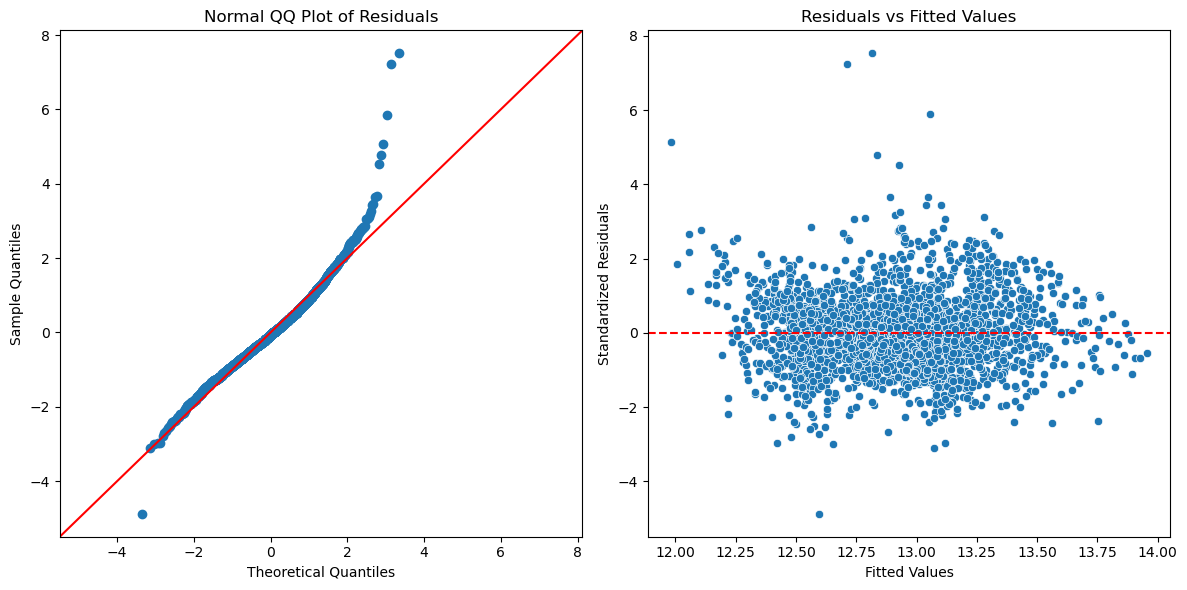

In [367]:
M2 = smf.ols(formula='np.log(resale_price) ~ storey_avg + floor_area_sqm + remaining_lease + C(town) + dist_to_mrt', data=data).fit()

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

residuals = M2.resid
fitted_values = M2.fittedvalues
standardized_residuals = M2.get_influence().resid_studentized_internal

# Plot 1: QQ Plot
sm.qqplot(residuals, line='45', fit=True, ax=axes[0])
axes[0].set_title("Normal QQ Plot of Residuals")

# Plot 2: Residuals vs Fitted
sns.scatterplot(x=fitted_values, y=standardized_residuals, ax=axes[1])
axes[1].axhline(y=0, color='red', linestyle='--')
axes[1].set_title("Residuals vs Fitted Values")
axes[1].set_xlabel("Fitted Values")
axes[1].set_ylabel("Standardized Residuals")

plt.tight_layout()
plt.show()

Comments: 

- __Residual Variance:__ As observed in the updated plots, the residuals versus fitted values scatterplot now displays a random dispersion, lacking the previous U-shaped and funnel-like patterns. This indicates that the transformation successfully stabilized the variance, satisfying the homoscedasticity assumption.
- __Residual Normality:__ Despite the variance improvements, the Normal Q-Q plot continues to exhibit an upward deviation from the reference line in the right tail. This suggests that while the core distribution is normalized, extreme values or outliers remain present in the upper quantiles of the dataset. Further experiments show that removing these outliers will give a better residual normality. However, removing these values may be dangerous as it can give us a false sense of precision in estimation/prediction.

In [368]:
influence = M2.get_influence()

standardized_residuals = influence.resid_studentized_internal
data['std_resid'] = standardized_residuals
outliers = data[(data['std_resid'] > 4) | (data['std_resid'] < -4)]

columns_to_view = ['town', 'flat_type', 'floor_area_sqm', 'resale_price', 'std_resid']
(outliers.sort_values(by='std_resid', ascending=False))

,town,flat_type,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price,lat,lon,dist_to_cbd,dist_to_mrt,storey_avg,std_resid
1542,QUEENSTOWN,3 ROOM,01 TO 03,87.0,Terrace,1968,565,830000.0,1.296589,103.804175,5.446844,0.309947,2.0,7.532330
377,BUKIT MERAH,3 ROOM,01 TO 03,75.0,Standard,1973,619,723000.0,1.284080,103.830526,2.331757,0.457152,2.0,7.233760
1179,KALLANG/WHAMPOA,3 ROOM,01 TO 03,126.0,Terrace,1972,612,880000.0,1.328532,103.857852,5.012881,1.102944,2.0,5.896935
1222,PASIR RIS,3 ROOM,04 TO 06,66.0,Improved,1981,720,277000.0,1.388853,103.986846,19.041229,3.490583,5.0,5.147086
1093,JURONG WEST,4 ROOM,04 TO 06,91.0,DBSS,2014,1119,630000.0,1.327937,103.724178,14.976954,1.850110,5.0,4.785331
1094,JURONG WEST,4 ROOM,16 TO 18,89.0,DBSS,2014,1118,670000.0,1.328460,103.723288,15.089544,1.775892,17.0,4.521885
56,ANG MO KIO,3 ROOM,10 TO 12,67.0,New Generation,1980,708,174000.0,1.374431,103.850157,10.067739,0.504598,11.0,-4.870558


#### Ridge Regression Experiment

As seen in the transforming target section before, doing the log transformation to the target makes the constant assumption is satisfied. However, since we still have problems with multicollinearity, we will experiment on utilizing ridge regression to solve this issue without dropping any variable. 

In [369]:
X = data[['resale_price', 'town', 'flat_type', 'flat_model', 'storey_avg', 'floor_area_sqm', 'remaining_lease', 'dist_to_cbd', 'dist_to_mrt']]

df_encoded = pd.get_dummies(X, columns=['town', 'flat_type', 'flat_model'], drop_first=True)
X = df_encoded.drop('resale_price', axis=1)
y = np.log(df_encoded['resale_price'])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Find the best Alpha (λ) using Cross-Validation
ridge_cv = RidgeCV(alphas=np.logspace(-3, 3, 1))
ridge_cv.fit(X_scaled, y)
best_alpha = ridge_cv.alpha_

ridge_model = Ridge(alpha=best_alpha)
ridge_model.fit(X_scaled, y)
y_pred = ridge_model.predict(X_scaled)

# Calculate Metrics
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y, y_pred)
mae = mean_absolute_error(y, y_pred)
n = X_scaled.shape[0]
p = X_scaled.shape[1]
adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print(f"{' RIDGE REGRESSION SUMMARY ':=^40}")
print(f"Best Alpha (λ):      {best_alpha:.4f}")
print(f"R-squared:           {r2:.4f}")
print(f"Adjusted R-squared:  {adjusted_r2:.4f}")
print(f"Mean Squared Error:  {mse:.4f}")
print(f"Root MSE:            {rmse:.4f}")
print(f"Mean Absolute Error: {mae:.4f}")
print("-" * 40)
print("Coefficients:")
coeff_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': ridge_model.coef_})
print(coeff_df.to_string(index=False))
print(f"Intercept:           {ridge_model.intercept_:.4f}")
print(f"{'='*40}")

======= RIDGE REGRESSION SUMMARY =======
Best Alpha (λ):      0.0010
R-squared:           0.9247
Adjusted R-squared:  0.9231
Mean Squared Error:  0.0085
Root MSE:            0.0921
Mean Absolute Error: 0.0696
----------------------------------------
Coefficients:
                          Feature  Coefficient
                       storey_avg     0.045620
                   floor_area_sqm     0.224646
                  remaining_lease     0.167000
                      dist_to_cbd    -0.086473
                      dist_to_mrt    -0.050240
                       town_BEDOK    -0.002623
                      town_BISHAN     0.019956
                 town_BUKIT BATOK    -0.012488
                 town_BUKIT MERAH     0.019671
               town_BUKIT PANJANG    -0.038760
                 town_BUKIT TIMAH     0.014989
                town_CENTRAL AREA     0.015927
               town_CHOA CHU KANG    -0.037518
                    town_CLEMENTI     0.014185
                     town_GEYLA

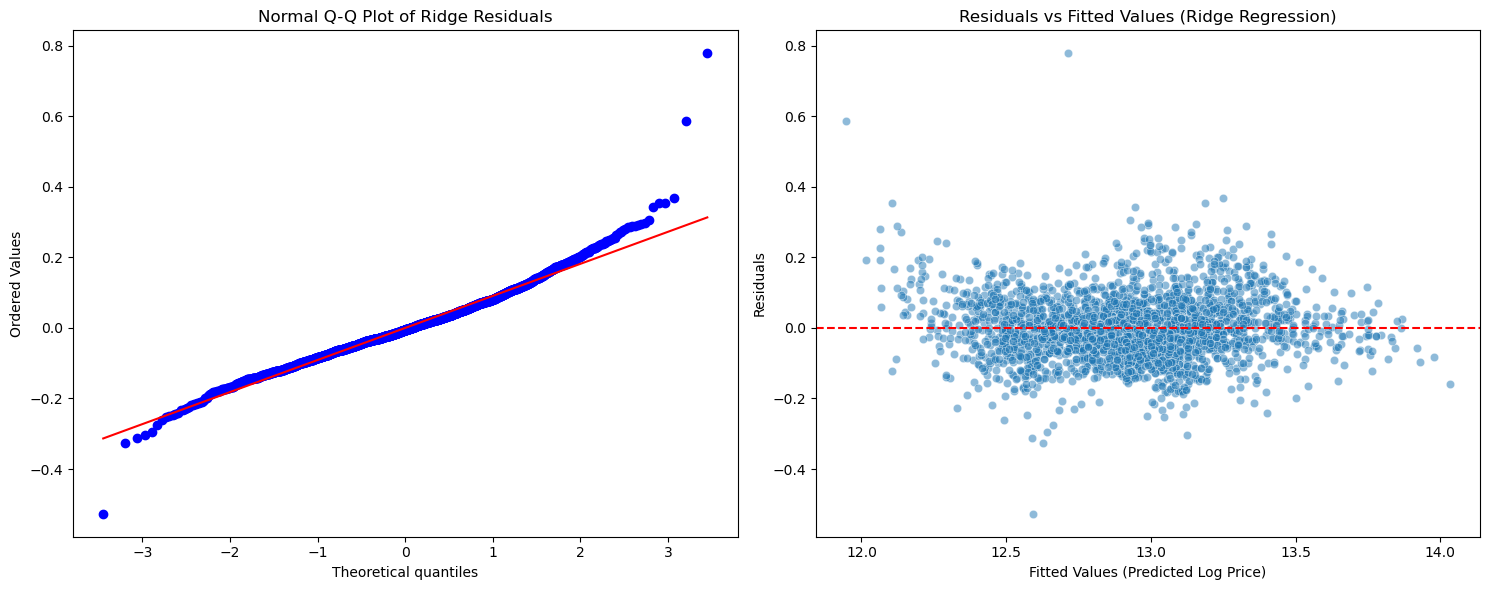

In [370]:
residuals = y - y_pred

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# QQ Plot 
stats.probplot(residuals, dist="norm", plot=axes[0])
axes[0].set_title('Normal Q-Q Plot of Ridge Residuals')

# Scatter plot of residuals 
sns.scatterplot(x=y_pred, y=residuals, alpha=0.5, ax=axes[1])
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('Residuals vs Fitted Values (Ridge Regression)')
axes[1].set_xlabel('Fitted Values (Predicted Log Price)')
axes[1].set_ylabel('Residuals')

plt.tight_layout()
plt.show()

Comments: 

- __Interpretability vs. Performance:__ Although the Ridge model yields a higher raw $R^2$ (92.47%), this is largely an artifact of retaining the massive, unpruned feature space (including dozens of categorical dummy variables). Furthermore, the L2 penalty introduces intentional bias to the coefficients, making it impossible to interpret the exact financial impact of individual predictors compared to standard Ordinary Least Squares (OLS).
- __Handling Multicollinearity:__ Ridge effectively mitigates severe multicollinearity by penalizing highly correlated variables, stabilizing the model without requiring feature elimination.
- __Bias-Variance Trade-off:__ By shrinking large coefficients, the model trades a small amount of bias for a significant reduction in variance, resulting in a more robust and generalizable predictive model.
- __Feature Retention:__ This approach preserves the entire feature space, ensuring the predictive power of all spatial and structural variables is maintained.


### Conclusion

In conclusion, the log-transformed Ordinary Least Squares (OLS) model utilizing five predictors (town, floor_area_sqm, remaining_lease, storey_avg, and dist_to_mrt) is selected as the optimal final model ($M_N$). This model demonstrates strong predictive capability, explaining approximately 89.5% of the variance in HDB resale prices. Through strategic feature selection and response transformation, the model successfully resolves initial issues of severe multicollinearity and heteroscedasticity. While minor deviations from normality remain in the upper tail of the residuals, this is an acceptable tradeoff, as these outliers represent valid, genuine transactions of ultra-premium flats rather than data errors.

Furthermore, while a penalized Ridge Regression was evaluated and yielded a marginally higher $R^2$ of 92.47%, it was ultimately rejected. Achieving this minor 3% increase in predictive power required massive feature retention, data scaling, and coefficient shrinkage, which compromises the real-world interpretability of the parameters. As a conclusion, the Log-OLS model is chosen as it provides the most effective balance of high predictive accuracy, structural soundness, and clear, actionable interpretability for the final coefficients.